In [1]:
import sys
sys.path.append("/Users/sophia/Desktop/Fundamentals_of_Bioinformatics/BioInfoFinalProject")

In [2]:
import matplotlib.pyplot as plt
import anndata as ad
from trajectory_inference.Laplacian_Eigenmaps import loadAndCSR, laplacianEigenmaps, pseudotime
adata = ad.read_h5ad("../data/wt_data.h5ad")

Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Embedding shape (1029, 2)
Pseudotime range -3.136550208718893 3.134970543292918
Eigenvalues: [0.07382296 0.10627053]


In [3]:
# want k values that generate small eigenvalues close in value (ratio ~ 1)

kVals = list(range(3, 21, 2))

for k in kVals:
    csr = loadAndCSR(adata, k = k)
    emb, ev = laplacianEigenmaps(csr)
    evRatio = ev[1] / ev[0]
    print(f"k = {k}, eigenvals = {ev}, eigenval ratio = {evRatio}")

Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 3, eigenvals = [0.00420173 0.0314636 ], eigenval ratio = 7.4882431055043845
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 5, eigenvals = [0.04317249 0.0627999 ], eigenval ratio = 1.4546275975773144
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 7, eigenvals = [0.05146459 0.0765278 ], eigenval ratio = 1.4869990314779136
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 9, eigenvals = [0.05920137 0.08476908], eigenval ratio = 1.4318771816238038
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 11, eigenvals = [0.0080791  0.06423209], eigenval ratio = 7.950398071812397
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 13, eigenvals = [0.0688384  0.09886022], eigenval ratio = 1.436120327280373
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 15, eigenval

Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...


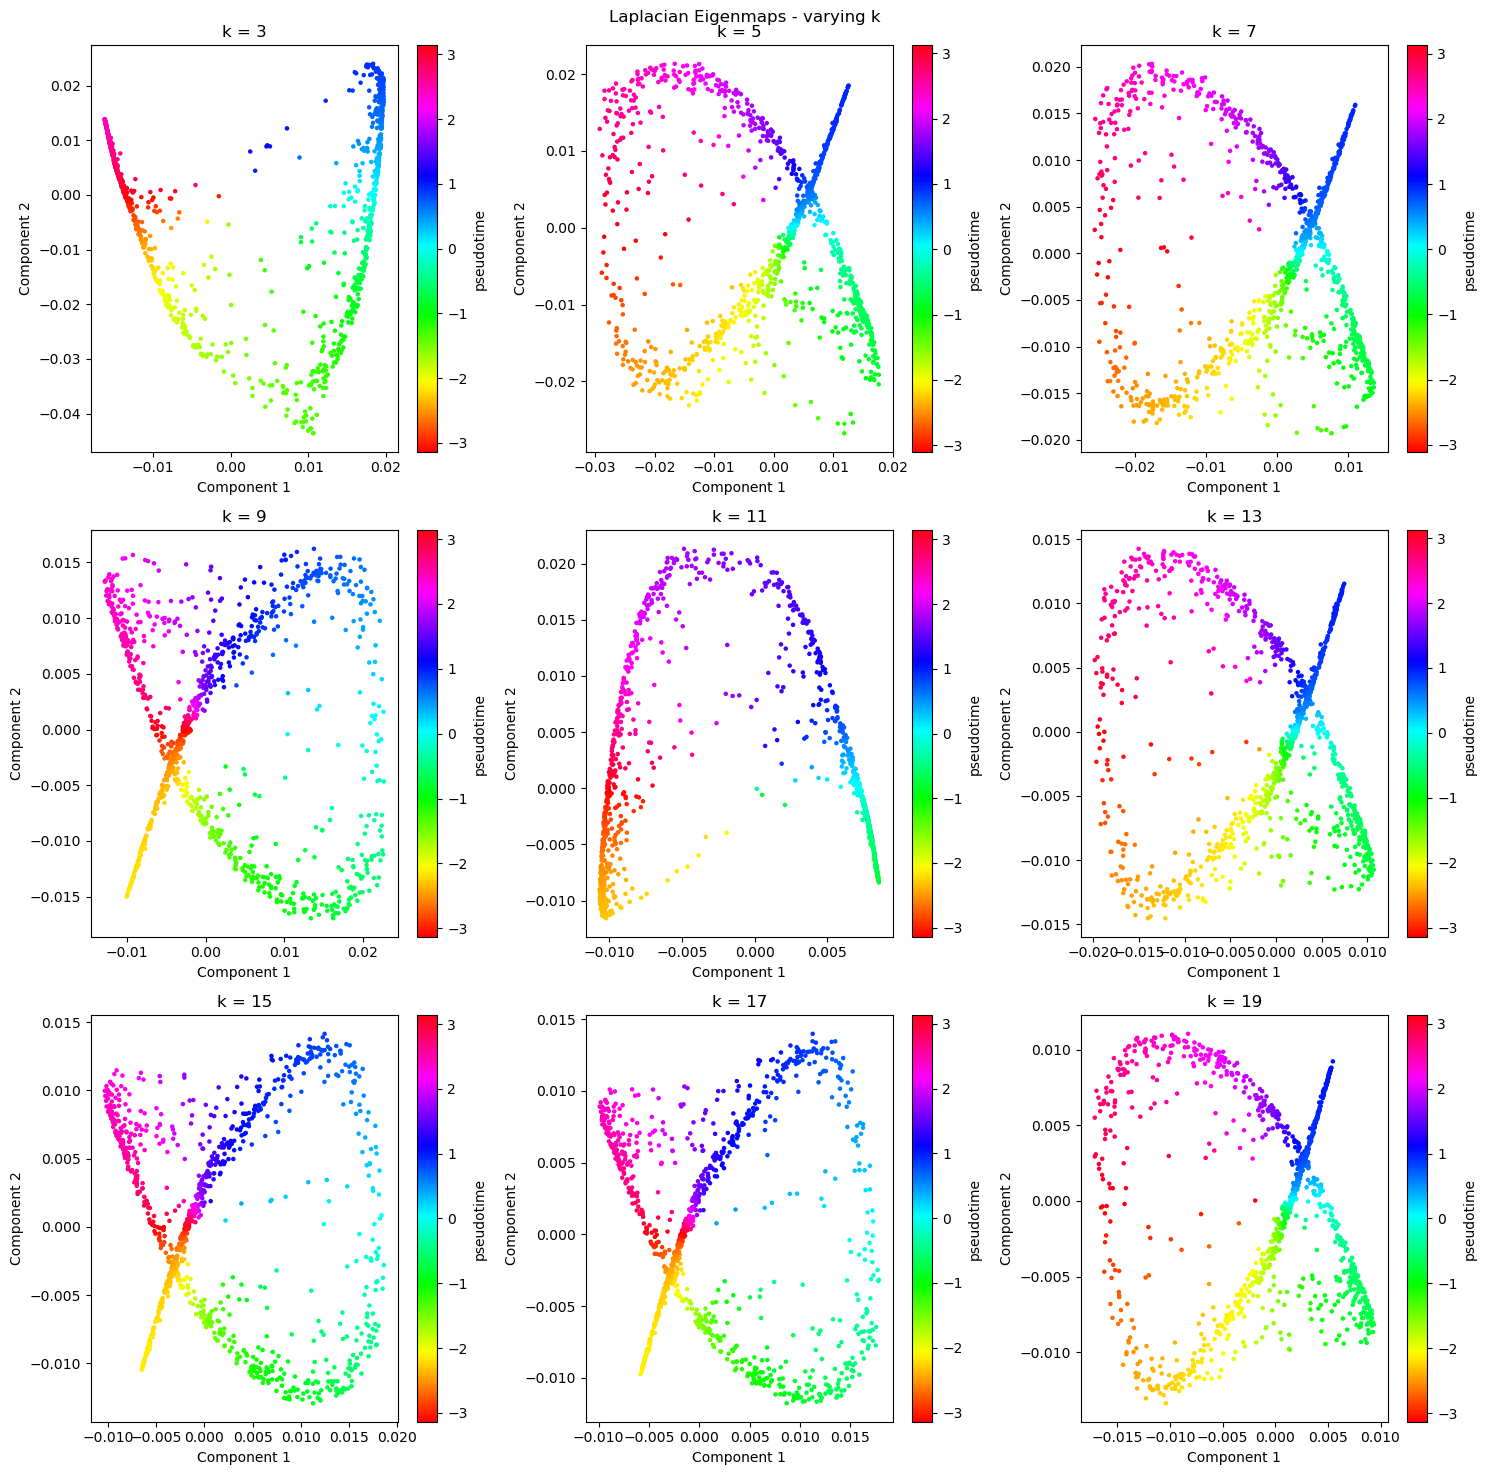

In [4]:
# checking plots with varying k clusters in kNN

kVals = list(range(3, 21, 2))
fig, axes = plt.subplots(3, 3, figsize = (15, 15))
axes = axes.flatten()

for i, k in enumerate(kVals):
    csr = loadAndCSR(adata, k = k)
    embeddings, eigvals = laplacianEigenmaps(csr)
    ps = pseudotime(embeddings)
    sc = axes[i].scatter(embeddings[:, 0], embeddings[:, 1], c = ps, cmap = "hsv", s = 5)
    axes[i].set_title(f"k = {k}")
    axes[i].set_xlabel("Component 1")
    axes[i].set_ylabel("Component 2")
    plt.colorbar(sc, ax = axes[i], label = "pseudotime")

plt.suptitle("Laplacian Eigenmaps - varying k")
plt.tight_layout()
plt.show()

Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...


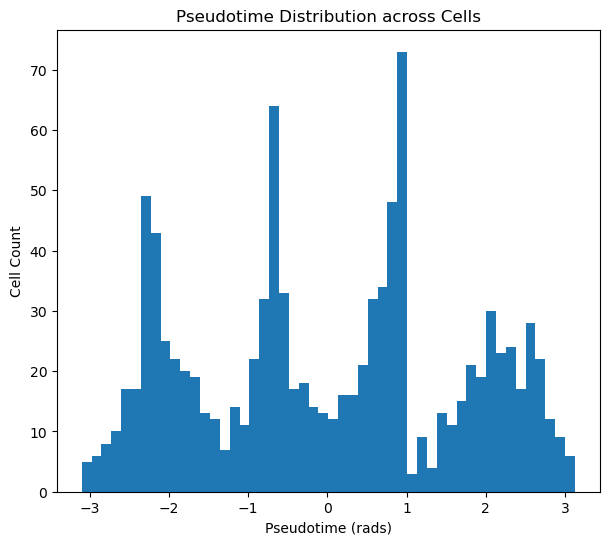

In [6]:
# plot of pseudotime distribution
csr = loadAndCSR(adata, k = 5)
embedding, eigvals = laplacianEigenmaps(csr)
pseudo = pseudotime(embedding)

plt.figure(figsize = (7, 6))
plt.hist(pseudo, bins = 50)
plt.xlabel("Pseudotime (rads)")
plt.ylabel("Cell Count")
plt.title("Pseudotime Distribution across Cells")
plt.show()